## Numerical Analysis - Spring semester 2026
# Serie 11 - Curve fitting

First, we will need to import some of the usual packages. You will have to run this cell every time you restart your notebook.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

<hr style="clear:both">

### Simple polynomial interpolation

We have the following data

\begin{align*}
x_0=0 \quad  & y_0=12, \\
x_1=1 \quad  & y_1=18, \\
x_2=2 \quad  & y_2=6.
\end{align*}

<div class="alert alert-success">

**Exercise 1:** Find the second order polynomial interpolating the data by setting up and solving the linear system with the Vandermonde matrix.
</div>

In [ ]:
### BEGIN SOLUTION
V = np.array([[1, 0, 0],
              [1, 1, 1],
              [1, 2, 4]])

y = np.array([12, 18, 6])
a = np.linalg.solve(V, y)
print(f"the interpolating polynomial is p₂(x) = {a[0]} + {a[1]} * x + {a[2]} * x^2")
### END SOLUTION

<div class="alert alert-success">

**Exercise 2:** Find the second order polynomial interpolating the data by using `np.polyfit`, evaluate the resulting polynomial at $100$ evenly spaced points in the interval $[-1, 3]$ by using `np.polyval`, and use them to visualize the polynomial on the same plot with the data.

*Hint:* To plot individual data points, use `plt.scatter`. To find out more about a function's inputs and outputs, use `help(function_name)`.
</div>

In [ ]:
### BEGIN SOLUTION
x = np.array([0, 1, 2])
a = np.polyfit(x, y, 2)
x_lin = np.linspace(-1, 3, 100)
y_lin = np.polyval(a, x_lin)
plt.scatter(x, y, label=r"data $(x_i, y_i)$")
plt.plot(x_lin, y_lin, label=r"interpolant $p_2(x)$")
plt.grid()
plt.ylabel(r"$y$")
plt.xlabel(r"$x$")
plt.legend()
plt.show()
### END SOLUTION

<div class="alert alert-success">

**Exercise 3 (Theoretical):** Find the three polynomials of the Lagrangian basis corresponding to the points $x_0=0, x_1=1$ and $x_2=2$.
</div>

=== BEGIN MARK SCHEME ===

Using the formula from Definition 2.2

\begin{align*}
\phi_i(x)=\prod_{\stackrel{j=0}{j\neq i}}^2 \frac{x-x_j}{x_i-x_j}, \quad \quad i=0,1,2.
\end{align*}

we find the Lagrangian polynomials by replacing the values of $x_0 = 0$, $x_1 = 1$, and $x_2 = 2$ to get

\begin{align*}
& \phi_0(x)=\frac{x-x_1}{x_0-x_1}\cdot \frac{x-x_2}{x_0-x_2}= \frac{(x-1)(x-2)}{2}\\
& \phi_1(x)=\frac{x-x_0}{x_1-x_0}\cdot \frac{x-x_2}{x_1-x_2}= -x(x-2)\\
& \phi_2(x)=\frac{x-x_0}{x_2-x_0}\cdot \frac{x-x_1}{x_2-x_1}= \frac{x(x-1)}{2}.  
\end{align*}

=== END MARK SCHEME ===

<div class="alert alert-success">

**Exercise 4 (Theoretical):** Using your result from the previous exercise, write down the second order polynomial interpolating the data. Compare the resulting polynomial to what you have found with the Vandermonde matrix at the beginning of this section.
</div>

=== BEGIN MARK SCHEME ===

The sought polynomial is given by

$$
p_2(x)= y_0 \phi_0(x) + y_1 \phi_1(x) + y_2 \phi_2(x).
$$

Inserting the Lagrange polynomials from the previous exercise and the $y$-data, we get

\begin{align*}
p_2(x)=& 6(x-1)(x-2)-18 x(x-2)+3x(x-1)\\
=& -9 x^2 + 15 x + 12.
\end{align*}

This is the same polynomial as we have found earlier in the section.

=== END MARK SCHEME ===

<hr style="clear:both">

### Interpolating functions at uniform and non-uniform nodes

We are given the data $(x_i,y_i)$, $i=0,1,\ldots,n$, where the $x_i$ are $n+1$ nodes in the interval $[a,b]=[-5,5]$ and
the values $y_i$ come from evaluation of the *Runge* function
$$
  g(x)= \frac{1}{1+x^2}
$$
without any measurement error, namely $y_i = g(x_i)$.  We want
to apply polynomial interpolation to the function $g$ from the data $(x_i,y_i)$.

<div class="alert alert-success">

**Exercise 5:** For degrees $n=6$ and $n=12$, compute the polynomial $p_n$ interpolating the data $(x_i,y_i)$, $i=0,1,...,n$ with uniformly spaced nodes

\begin{equation*}
    x_i = a + \frac{i}{n} (b - a), ~i=0,1,...,n.
\end{equation*}

Visualize the function and the interpolating polynomial at $1'000$ evenly spaced points in the interval $[-5, 5]$. What do you observe?
</div>

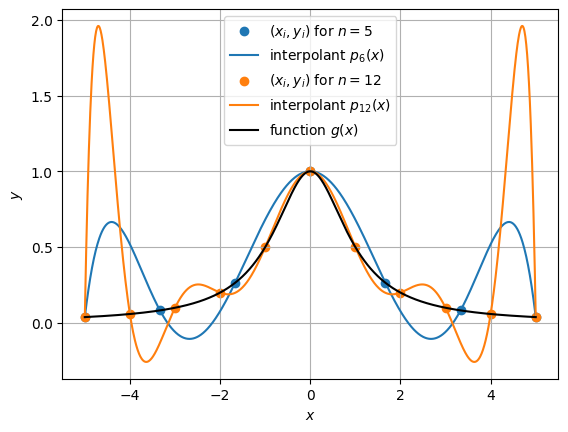

In [3]:
### BEGIN SOLUTION
def g(x):
    return 1 / (1 + x ** 2)

x_lin = np.linspace(-5, 5, 1000)
y_lin = g(x_lin)

x_6_unif = - 5 + np.arange(6 + 1) / 6 * (5 - (- 5))
y_6_unif = g(x_6_unif)
a_6_unif = np.polyfit(x_6_unif, y_6_unif, 6)
y_lin_6_unif = np.polyval(a_6_unif, x_lin)

x_12_unif = - 5 + np.arange(10 + 1) / 10 * (5 - (- 5))
y_12_unif = g(x_12_unif)
a_12_unif = np.polyfit(x_12_unif, y_12_unif, 10)
y_lin_12_unif = np.polyval(a_12_unif, x_lin)

plt.scatter(x_6_unif, y_6_unif, label=r"$(x_i, y_i)$ for $n = 5$")
plt.plot(x_lin, y_lin_6_unif, label=r"interpolant $p_6(x)$")
plt.scatter(x_12_unif, y_12_unif, label=r"$(x_i, y_i)$ for $n = 12$")
plt.plot(x_lin, y_lin_12_unif, label=r"interpolant $p_{12}(x)$")
plt.plot(x_lin, y_lin, label=r"function $g(x)$", color="black")
plt.grid()
plt.ylabel(r"$y$")
plt.xlabel(r"$x$")
plt.legend()
plt.show()
### END SOLUTION

<div class="alert alert-success">

**Exercise 6:** Repeat the previous exercise for the Chebyshev nodes, i.e. nodes which are given by

\begin{equation*}
    x_i = \frac{b+a}{2} - \frac{b-a}{2} \cos\left(\frac{(i+1/2)\pi}{n+1}\right),  ~i=0,1,...,n.
\end{equation*}

Compare the result to the previous exercise. Explain the difference using what you have learned in the lecture.

</div>

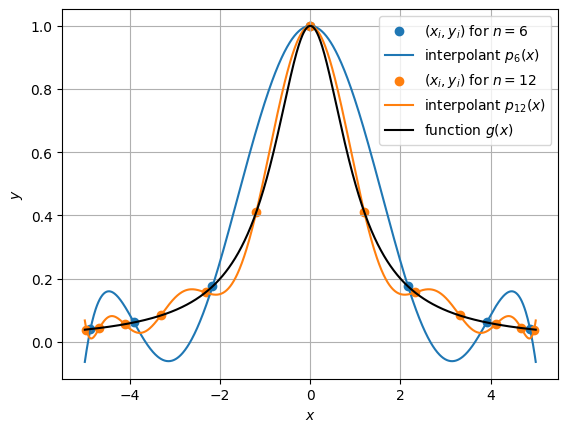

In [4]:
### BEGIN SOLUTION
x_6_cc = (5 + (- 5)) / 2 - (5 - (- 5)) / 2 * np.cos(np.pi * (np.arange(6 + 1) + 0.5) / 7) 
y_6_cc = g(x_6_cc)
a_6_cc = np.polyfit(x_6_cc, y_6_cc, 6)
y_lin_6_cc = np.polyval(a_6_cc, x_lin)

x_12_cc = (5 + (- 5)) / 2 - (5 - (- 5)) / 2 * np.cos(np.pi * (np.arange(12 + 1) + 0.5) / 13) 
y_12_cc = g(x_12_cc)
a_12_cc = np.polyfit(x_12_cc, y_12_cc, 12)
y_lin_12_cc = np.polyval(a_12_cc, x_lin)

plt.scatter(x_6_cc, y_6_cc, label=r"$(x_i, y_i)$ for $n = 6$")
plt.plot(x_lin, y_lin_6_cc, label=r"interpolant $p_6(x)$")
plt.scatter(x_12_cc, y_12_cc, label=r"$(x_i, y_i)$ for $n = 12$")
plt.plot(x_lin, y_lin_12_cc, label=r"interpolant $p_{12}(x)$")
plt.plot(x_lin, y_lin, label=r"function $g(x)$", color="black")
plt.grid()
plt.ylabel(r"$y$")
plt.xlabel(r"$x$")
plt.legend()
plt.show()

# Difference: Much better approximation for Chebyshev nodes.
# Explanation: Chebyshev nodes have a slower growing Lebesgue constant than uniformly spaced nodes.
# Therefore, by Definition 2.4, the interpolation is much more stable.

### END SOLUTION

<div class="alert alert-success">
    
**Exercise 7 (Theoretical):** Let $a, b \in \mathbb{R}$ such that $a < b$. Given $n \in \mathbb{N} \setminus \{0\}$, define $h = (b-a)/n$ and, for all $i \in \{0, \dots, n\}$, $x_i = a+hi$. Prove that, for all $x \in [a, b]$

$$
\left|\prod_{i=0}^n (x-x_i)\right| \le n! h^{n+1} / 4.
$$
</div>

=== BEGIN MARK SCHEME ===

Fix any $j \in \{0, \dots, n-1\}$ and assume that $x \in (x_j, x_{j+1})$. Then
$$
\prod_{i=0}^n (x-x_i) = (x - x_j)(x - x_{j+1}) \prod_{i=0}^{j-1} (x-x_i) \prod_{i=j + 2}^{n} (x-x_i)
$$
The polynomial $(x - x_j)(x - x_{j+1})$ takes its maximum at $x = (x_j + x_{j+1})/2$, which can be shown by determining where its derivative vanishes. Hence, $|(x - x_j)(x - x_{j+1})| \leq h^2 / 4$. The remaining factors are bound by $h^{n-1} n!$, since $|x - x_i| \leq (|j - i| + 1) h,~\forall i$. Consequently, we have  
$$
\left| \prod_{i=0}^n (x-x_i) \right| \leq \frac{n! h^{n+1}}{4}
$$
as was to be shown.


=== END MARK SCHEME ===

<div class="alert alert-success">
    
**Exercise 8 (Theoretical):** Use the bound from the previous exercise and a theorem seen in a lecture that if $f \in \mathrm{C}^{n+1}([a, b], \mathbb{R})$ and $p_n : \mathbb{R} \to \mathbb{R}$ is the polynomial function of degree at most $n$ such that $p_n(x_i) = f(x_i)$ for all $i \in \{0, \dots, n\}$, then
\begin{equation*}
\max_{x \in [a, b]} |f(x)-p_n(x)| \le \frac{1}{4(n+1)} \left(\frac{b-a}{n}\right)^{n+1} \max_{x \in [a, b]} |f^{(n+1)}(x)|.
\end{equation*}
</div>

=== BEGIN MARK SCHEME ===

From a theorem in the lectures, we know that for such a function $f$ and an interpolating polynomial $p_n$ it holds

$$
f(x) = p_n(x) + \frac{f^{(n+1)}(c)}{(n+1)!} \prod_{i=0}^{n} (x - x_i)
$$

for some $c \in (a, b)$. Therefore, rearranging this expression, taking its magnitude, and finally the maximum with respect to $x$ gives

$$
\max_{x \in [a, b]} |f(x) - p_n(x)| = \frac{1}{(n+1)!} \left| f^{(n+1)}(c) \right| \max_{x \in [a, b]} \left|\prod_{i=0}^{n} (x - x_i)\right|
$$

The second term on the right-hand side can be bound using the previous exercise and the first one by taking the maximum with respect to $c$

$$
\max_{x \in [a, b]} |f(x) - p_n(x)| \leq \frac{1}{(n+1)!} \max_{x \in [a,b]} \left| f^{(n+1)}(x) \right| \frac{n! h^{n+1}}{4} = \frac{1}{4(n+1)} \left(\frac{b-a}{n}\right)^{n+1} \max_{x \in [a, b]} |f^{(n+1)}(x)|,
$$

where we used the definition $h = (b - a)/n$.

=== END MARK SCHEME ===

<hr style="clear:both">

### Interpolation with cubic splines

Similar to the previous exercise consider the data $(x_i,y_i)$, $i=0,1,\ldots,n$, where the $x_i$ are $n+1$ nodes in the interval $[a,b]=[-5,5]$ and the values $y_i$ come from evaluation of the *Runge* function
$$
  g(x)= \frac{1}{1+x^2}
$$
without any measurement error, namely $y_i = g(x_i)$, and want to analyze the accuracy of different polynomial interpolation strategies of $g$ for the data $(x_i,y_i)$. To measure the accuracy, we compute the maximum absolute error the interpolant makes on a set of points `x_eval` specified by the user.
The below two functions do this for the interpolants with uniform and Chebyshev nodes based on last week's implementations.  

In [ ]:
def uniform_interpolation_error(g, a, b, n, x_eval):
    x_unif = a + np.arange(n + 1) / n * (b - a)
    y_unif = g(x_unif)
    a_unif = np.polyfit(x_unif, y_unif, n)
    y_eval = np.polyval(a_unif, x_eval)
    error = np.max(np.abs(y_eval - g(x_eval)))
    return error

def chebyshev_interpolation_error(g, a, b, n, x_eval):
    x_cheb = (a + b) / 2 - (b - a) / 2 * np.cos(np.pi * (np.arange(n + 1) + 0.5) / (n + 1)) 
    y_cheb = g(x_cheb)
    a_cheb = np.polyfit(x_cheb, y_cheb, n)
    y_eval = np.polyval(a_cheb, x_eval)
    error = np.max(np.abs(y_eval - g(x_eval)))
    return error

<div class="alert alert-success">

**Exercise 9:** Create an equivalent function for cubic spline interpolation.

*Hint:* The SciPy function `spline = sp.interpolate.CubicSpline(x, y)` interpolates some data `x` and `y` with a cubic spline, and returns a a function `spline`, which can be called to evaluate the spline at some points. 
</div>

In [6]:
def spline_interpolation_error(g, a, b, n, x_eval):
    ### BEGIN SOLUTION
    x_unif = a + np.arange(n + 1) / n * (b - a)
    y_unif = g(x_unif)
    spline = sp.interpolate.CubicSpline(x_unif, y_unif)
    y_eval = spline(x_eval)
    error = np.max(np.abs(y_eval - g(x_eval)))
    ### END SOLUTION
    return error

<div class="alert alert-success">

**Exercise 10:** For $n=1, 3, 5, ..., 25$, compute the errors of the three methods (uniform, Chebyshev, spline) and visualize them in the same plot with a logarithmic $y$-axis. Choose `x_eval` as 1'000 uniformly spaced values in $[-5, 5]$. What do you observe?
</div>

In [ ]:
def g(x):
    return 1 / (1 + x ** 2)

a = -5
b = 5
x_eval = np.linspace(-5, 5, 1000)

### BEGIN SOLUTION
n_list = np.arange(1, 25, 2)
uniform_interpolant_errors = []
chebyshev_interpolant_errors = []
spline_interpolant_errors = []

for n in n_list:
    uniform_interpolant_errors.append(uniform_interpolation_error(g, a, b, n, x_eval))
    chebyshev_interpolant_errors.append(chebyshev_interpolation_error(g, a, b, n, x_eval))
    spline_interpolant_errors.append(spline_interpolation_error(g, a, b, n, x_eval))

plt.semilogy(n_list, uniform_interpolant_errors, label=r"uniform interpolant")
plt.semilogy(n_list, chebyshev_interpolant_errors, label=r"Chebyshev interpolant")
plt.semilogy(n_list, spline_interpolant_errors, label=r"spline interpolant")
plt.grid()
plt.ylabel(r"error")
plt.xlabel(r"interpolation nodes $n$")
plt.legend()
plt.show()

# Spline interpolation has a smaller error than interpolation at Chebyshev nodes.

### END SOLUTION

Now, consider the functions

$$
g_1(x) = \sin(5 x)
$$

and 

$$
g_2(x) = x |x|
$$

on the interval $[-1, 1]$.

<div class="alert alert-success">
    
**Exercise 11:** Use cubic splines to interpolate the functions $g_1$ and $g_2$ at $n + 1$ equidistant nodes for $n = 2^k$ and $k = 4, 5, \dots, 8$ in the interval $[-1, 1]$. For every $h = 2 / n$, approximate the maximum absolute error by evaluating the spline and the function in $100$ equally spaced points within the interval $[-1, 1]$ and computing the maximum absolute distance attained in these points. Plot $E_{3, h}=\max_{x \in [-1, 1]} |g(x) - s_{3, h}(x)|$ against all $h$ for both functions in a log-log plot (use `plt.loglog` for this).
</div>

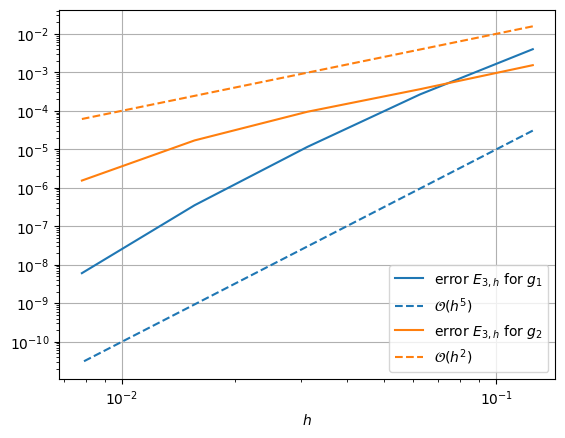

In [7]:
### BEGIN SOLUTION
def g_1(x):
    return np.sin(5 * x)

def g_2(x):
    return x * np.abs(x)

x_lin = np.linspace(-1, 1, 100)  # fine grid
errors_g_1 = []
errors_g_2 = []
n_list = 2 ** np.arange(4, 9)
h_list = 2 / n_list
for n in n_list:
    errors_g_1.append(spline_interpolation_error(g_1, -1, 1, n, x_lin))
    errors_g_2.append(spline_interpolation_error(g_2, -1, 1, n, x_lin))

plt.loglog(h_list, errors_g_1, label=r"error $E_{3, h}$ for $g_1$")
plt.loglog(h_list, np.array(h_list)**5, label=r"$\mathcal{O}(h^5)$", linestyle="--", color="tab:blue")
plt.loglog(h_list, errors_g_2, label=r"error $E_{3, h}$ for $g_2$")
plt.loglog(h_list, np.array(h_list)**2, label=r"$\mathcal{O}(h^2)$", linestyle="--", color="tab:orange")
plt.xlabel(r"$h$")
plt.grid()
plt.legend()
plt.show()

# The maximum absolute interpolation error of the interpolating spline for $g_1$
# goes down approximately as the line $h^5$. Therefore, we observe an even faster
# convergence than what is guaranteed by Theorem 2.4. 
# For $g_2$ the error goes down with $h^2$. As expected, the bound from Theorem 2.4
# does not hold in this case.

### END SOLUTION

<hr style="clear:both">

## The end

Splendid! You have reached the end of the eighth exercise notebook.